# 01 — Phát hiện STEMI

**Dự án ACS-ECG-AI (Vinmec)** · **Bài toán 2** — phát hiện nhồi máu cơ tim có ST chênh lên (STEMI)

Huấn luyện một mô hình **1D CNN residual** chạy trực tiếp trên tín hiệu ECG 12 chuyển đạo thô
(12 × 5000 mẫu @ 500 Hz) để dự đoán nhãn `STEMI`. Đầu ra là **xác suất liên tục**,
kèm đánh giá hiệu chuẩn và tối ưu ngưỡng.

Dữ liệu: *A large-scale 12-lead ECG dataset for acute coronary syndrome prediction containing
19,955 ECGs* (Du et al., Sci Data 13:1009, 2026) — DOI dữ liệu `10.6084/m9.figshare.29925314`.

> Notebook tự chứa, chạy được trên **Google Colab** lẫn **máy cá nhân**.
> Muốn so sánh nhiều kiến trúc mô hình khác nhau cho bài toán này, xem notebook `03_stemi_model_comparison.ipynb`.

## 1. Cài thư viện

Chỉ cài `wfdb` nếu môi trường chưa có. Trên Colab cần cài lại mỗi phiên (~10 giây).

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("wfdb") is None:
    print("Đang cài wfdb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb"], check=True)

import wfdb

print("wfdb", wfdb.__version__)

wfdb 4.3.1


## 2. Cấu hình

Notebook chạy được trên **Google Colab** và **máy cá nhân**, tự nhận diện môi trường.
Chỉ cần sửa đúng một chỗ:

- **Colab** → `DRIVE_PROJECT` (tên thư mục trên Drive chứa `datasets.zip`)
- **Máy cá nhân** → `LOCAL_DATA_ROOT`

Ngoài ra đổi `RUN_MODE` khi muốn chuyển từ chạy thử sang chạy thật.

**Thư mục `outputs/` chỉ giữ hai thứ:** checkpoint mô hình và cache tín hiệu. Hình và bảng số
đều hiển thị ngay trong notebook nên không ghi ra file nữa.

Trên Colab, cache đặt ở `/content` (nhanh, mất khi hết phiên) và được sao lưu lên Drive để phiên
sau khỏi tiền xử lý lại; checkpoint ghi thẳng lên Drive để không mất khi đứt phiên.

In [2]:
import os
from pathlib import Path

import torch

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"        # "debug" = 200 bản ghi / 3 epoch  |  "full" = toàn bộ / 30 epoch

# ===================== ĐƯỜNG DẪN =======================
IS_COLAB = importlib.util.find_spec("google.colab") is not None

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    DATA_ROOT = Path("/content/datasets")      # giải nén ra đĩa local cho nhanh
    WORK_DIR = Path("/content/work")           # tạm, mất khi hết phiên
    PERSIST_DIR = DRIVE_PROJECT / "outputs"    # bền qua các phiên
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"                    # <<< SỬA khi chạy máy cá nhân
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"                     # cache tín hiệu (sinh lại được)
MODEL_DIR = PERSIST_DIR / "models" / "stemi"  # checkpoint (không được mất)
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None

# ===================== THAM SỐ =========================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12      # 12 chuyển đạo × 10 giây @ 500 Hz
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3       # bandpass Butterworth
VAL_SIZE = 0.15                                 # chia theo bệnh nhân 85/15
LR, WEIGHT_DECAY = 1e-3, 1e-4
EARLY_STOP_PATIENCE, LR_PATIENCE = 10, 5
ECE_BINS = 10
TARGET_LABEL = "STEMI"
CLASS_NAME = "STEMI"

# Số bản ghi trong paper (tính trên toàn bộ 19.955); ta chỉ có nhãn cho 90% nên dung sai ±10%
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197}
SANITY_TOL = 0.10

# ===================== SUY RA ==========================
GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
DEBUG_LIMIT = 200
EPOCHS = 3 if RUN_MODE == "debug" else 30
BATCH_SIZE = 8 if RUN_MODE == "debug" else (64 if GPU_AVAILABLE else 16)
USE_AMP = GPU_AVAILABLE

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Thiết bị   :", DEVICE)
print("Chế độ     :", RUN_MODE, f"({EPOCHS} epoch, batch {BATCH_SIZE})")
print("Nhãn đích  :", TARGET_LABEL)

Môi trường : máy cá nhân
Thiết bị   : cuda
Chế độ     : full (30 epoch, batch 64)
Nhãn đích  : STEMI


### 2b. Chuẩn bị dữ liệu

Trên máy cá nhân cell này chỉ tạo thư mục. Trên Colab nó mount Drive (sẽ hiện popup xin quyền —
đây là thao tác thủ công duy nhất), copy `datasets.zip` về `/content` rồi giải nén.

Phải đi vòng qua zip vì bộ dữ liệu có **59.867 file**, mà Drive tính mỗi lần mở file là một lệnh
gọi mạng — đọc trực tiếp từ Drive sẽ chậm hơn hàng chục lần.

In [3]:
import shutil
import time
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    """Tìm thư mục thật chứa dữ liệu, chịu được việc zip có bọc thêm lớp thư mục."""
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real

    if not DRIVE_DATA_ZIP.exists():
        có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(
            f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}"
        )

    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")

    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")

    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError(
            "DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount:\n"
            '    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")'
        )
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        có_gì = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(
            f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {có_gì}"
        )

for d in [CACHE_DIR, MODEL_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

DATA_ROOT: C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets | tồn tại: True


## 3. Seed & GPU

In [4]:
import random

import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Input cố định (12 × 5000) nên cuDNN chọn thuật toán nhanh nhất một lần rồi giữ nguyên.
# Đánh đổi: epoch đầu chậm hơn vài giây, và kết quả không tái lập chính xác 100%.
torch.backends.cudnn.benchmark = GPU_AVAILABLE

print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if GPU_AVAILABLE else "không có")
if IS_COLAB and not GPU_AVAILABLE:
    print("\n" + "!" * 70)
    print("!! COLAB KHÔNG CÓ GPU -> Runtime > Change runtime type > GPU, rồi Run all lại.")
    print("!" * 70)

torch 2.11.0+cu128 | GPU: NVIDIA RTX 2000 Ada Generation Laptop GPU


## 4. Dữ liệu và nhãn

Nhãn chỉ có trong `train.csv` (phần 90% chính thức). `test.csv` là tập test ẩn, không có cột nhãn
và **không bao giờ được đọc** trong notebook này.

Sanity check đối chiếu số ca với paper. Dung sai ±10% chứ không phải ±2%, vì số của paper tính trên
toàn bộ 19.955 bản ghi còn ta chỉ đếm được trên 90% có nhãn.

In [5]:
import pandas as pd

pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)

COL_PATIENT, COL_AGE, COL_GENDER = "Patient_id", "age", "gender"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

# --- Sanity check ---
print(f"\n{'nhãn':<8}{'đếm được':>11}{'paper':>9}{'lệch':>9}")
ok_all = True
for name, expected in PAPER_COUNTS.items():
    got = int(df_raw[name].sum())
    delta = (got - expected) / expected
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{name:<8}{got:>11,}{expected:>9,}{delta:>8.1%}   {'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print("\n!! CẢNH BÁO: số ca lệch quá ±10% so với paper — kiểm tra lại nguồn dữ liệu.")

# --- Nhãn đích ---
df_all = df_raw.copy()
df_all[TARGET_LABEL] = df_all["STEMI"].astype(int)
print("Nhãn = cột STEMI (lấy trực tiếp)")

n_pos = int(df_all[TARGET_LABEL].sum())
print(f"\nNhãn {TARGET_LABEL}: {n_pos:,} dương ({n_pos / len(df_all):.2%}) / "
      f"{len(df_all) - n_pos:,} âm")

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được    paper     lệch
STEMI         1,442    1,513   -4.7%   OK
NSTEMI        1,235    1,274   -3.1%   OK
UA            6,213    6,197    0.3%   OK
Nhãn = cột STEMI (lấy trực tiếp)

Nhãn STEMI: 1,442 dương (8.03%) / 16,518 âm


## 5. Lấy mẫu khi chạy thử

Ở `RUN_MODE="debug"` lấy 200 bản ghi **stratified** theo nhãn, để tập mẫu không rơi vào toàn 0
hoặc toàn 1 (khi đó mọi metric sẽ vô định).

In [6]:
from sklearn.model_selection import train_test_split

if RUN_MODE == "debug" and len(df_all) > DEBUG_LIMIT:
    df, _ = train_test_split(df_all, train_size=DEBUG_LIMIT,
                             stratify=df_all[TARGET_LABEL], random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_all.reset_index(drop=True)

n_pos = int(df[TARGET_LABEL].sum())
print(f"Dùng {len(df):,} bản ghi | {n_pos:,} dương ({n_pos / len(df):.2%})")
assert 0 < n_pos < len(df), "Tập chỉ có một lớp — không train được."

Dùng 17,960 bản ghi | 1,442 dương (8.03%)


## 6. Nhìn nhanh dữ liệu

Biểu đồ cuối là lý do phải chia train/val **theo bệnh nhân** chứ không theo bản ghi.

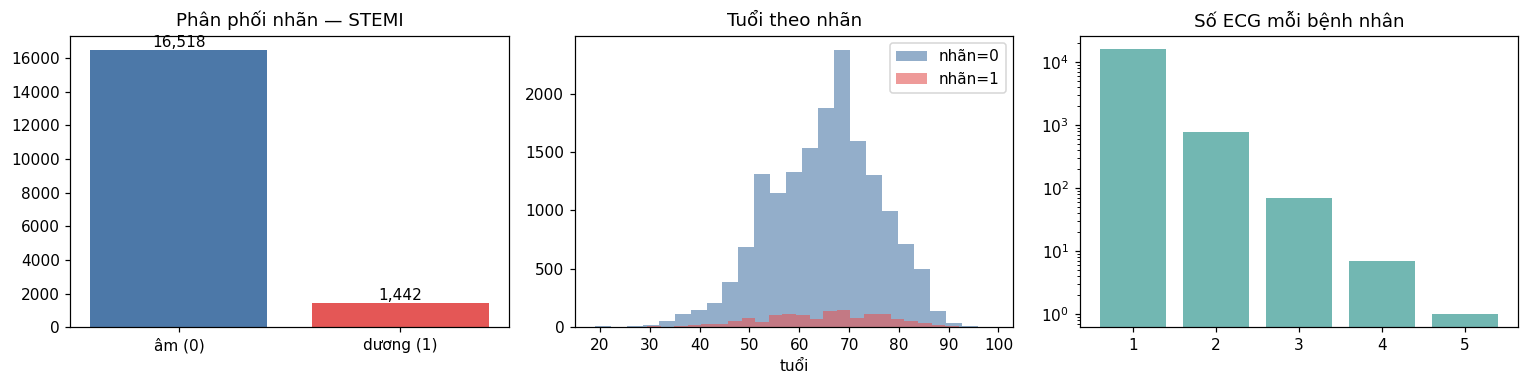

Bệnh nhân có >1 bản ghi: 855 | trong đó nhãn KHÔNG đồng nhất giữa các bản ghi của chính họ: 121


In [7]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

ax[0].bar(["âm (0)", "dương (1)"], [len(df) - n_pos, n_pos], color=["#4C78A8", "#E45756"])
ax[0].set_title(f"Phân phối nhãn — {TARGET_LABEL}")
for i, v in enumerate([len(df) - n_pos, n_pos]):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

for lab, c in [(0, "#4C78A8"), (1, "#E45756")]:
    ax[1].hist(df.loc[df[TARGET_LABEL] == lab, COL_AGE], bins=25, alpha=.6, label=f"nhãn={lab}", color=c)
ax[1].set_title("Tuổi theo nhãn")
ax[1].set_xlabel("tuổi")
ax[1].legend()

rp = df.groupby(COL_PATIENT).size().value_counts().sort_index()
ax[2].bar(rp.index.astype(str), rp.values, color="#72B7B2")
ax[2].set_title("Số ECG mỗi bệnh nhân")
ax[2].set_yscale("log")

plt.tight_layout()
plt.show()

incons = df.groupby(COL_PATIENT)[TARGET_LABEL].nunique()
print(f"Bệnh nhân có >1 bản ghi: {int((df.groupby(COL_PATIENT).size() > 1).sum()):,} | "
      f"trong đó nhãn KHÔNG đồng nhất giữa các bản ghi của chính họ: {int((incons > 1).sum()):,}")

## 7. Tiền xử lý và cache

Với mỗi bản ghi: đọc WFDB → NaN→0 → cắt/đệm về đúng 5000 mẫu → bandpass Butterworth 0,5–40 Hz
(`filtfilt`, zero-phase). **Chuẩn hoá z-score làm sau**, ở bước 9, với mean/std tính riêng trên tập
train để không rò rỉ thống kê của val sang train.

Lọc lại toàn bộ ở mỗi epoch là nút thắt cổ chai, nên tín hiệu đã lọc được cache **một lần** vào
memmap `float16` (~2,2 GB cho 17.960 bản ghi). Cache nối tiếp được nếu bị ngắt giữa chừng, và trên
Colab được sao lưu lên Drive.

> **Hai bản ghi lỗi trong dữ liệu gốc.** `03228` và `14262` có file `.dat` chỉ chứa 3.500/5.000 mẫu,
> khiến `wfdb.rdrecord()` báo lỗi. Hàm dưới bắt lỗi đó, đọc phần thực có rồi để bước zero-pad bù nốt.

In [8]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:                     # .dat ngắn hơn header khai báo
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p: Path, npy_p: Path) -> bool:
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache() -> np.ndarray:
    # Colab: thử lấy lại cache của phiên trước từ Drive
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            t0 = time.time()
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)
            print(f"  {time.time() - t0:.0f}s — bỏ qua tiền xử lý")

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))

    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            el = max(time.time() - t0, 1e-6)
            done = i + 1 - start
            print(f"  {i + 1:>6,}/{len(records):,}  {done / el:5.0f} rec/s  "
                  f"ETA {(len(records) - i - 1) / (done / el):4.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")

    if DRIVE_CACHE_DIR:
        print("Sao lưu cache lên Drive ...")
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn, đã zero-pad: {TRUNCATED}")

Build cache 17,960 bản ghi (~2.01 GB)


   2,245/17,960    334 rec/s  ETA   47s


   4,490/17,960    334 rec/s  ETA   40s


   6,735/17,960    334 rec/s  ETA   34s


   8,980/17,960    333 rec/s  ETA   27s


  11,225/17,960    333 rec/s  ETA   20s


  13,470/17,960    333 rec/s  ETA   13s


  15,715/17,960    335 rec/s  ETA    7s


  17,960/17,960    336 rec/s  ETA    0s
Xong trong 54s
Cache: (17960, 12, 5000) float16
Bản ghi bị cắt ngắn, đã zero-pad: ['14262', '03228']


## 8. Xem thử tín hiệu

Kiểm tra bằng mắt trước khi train: tín hiệu có ra hình dạng ECG không, có bị phẳng hay bão hoà không.

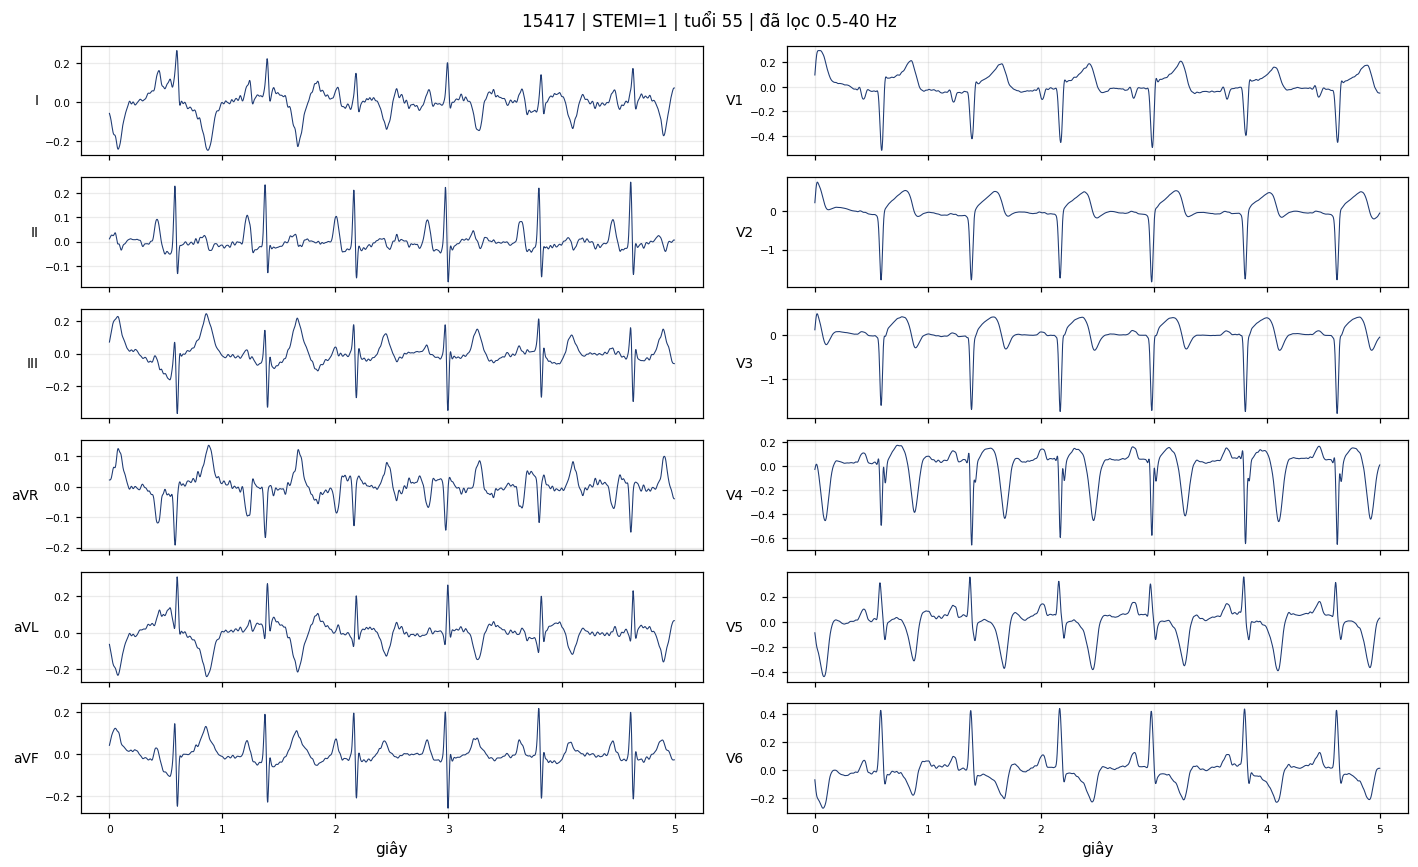

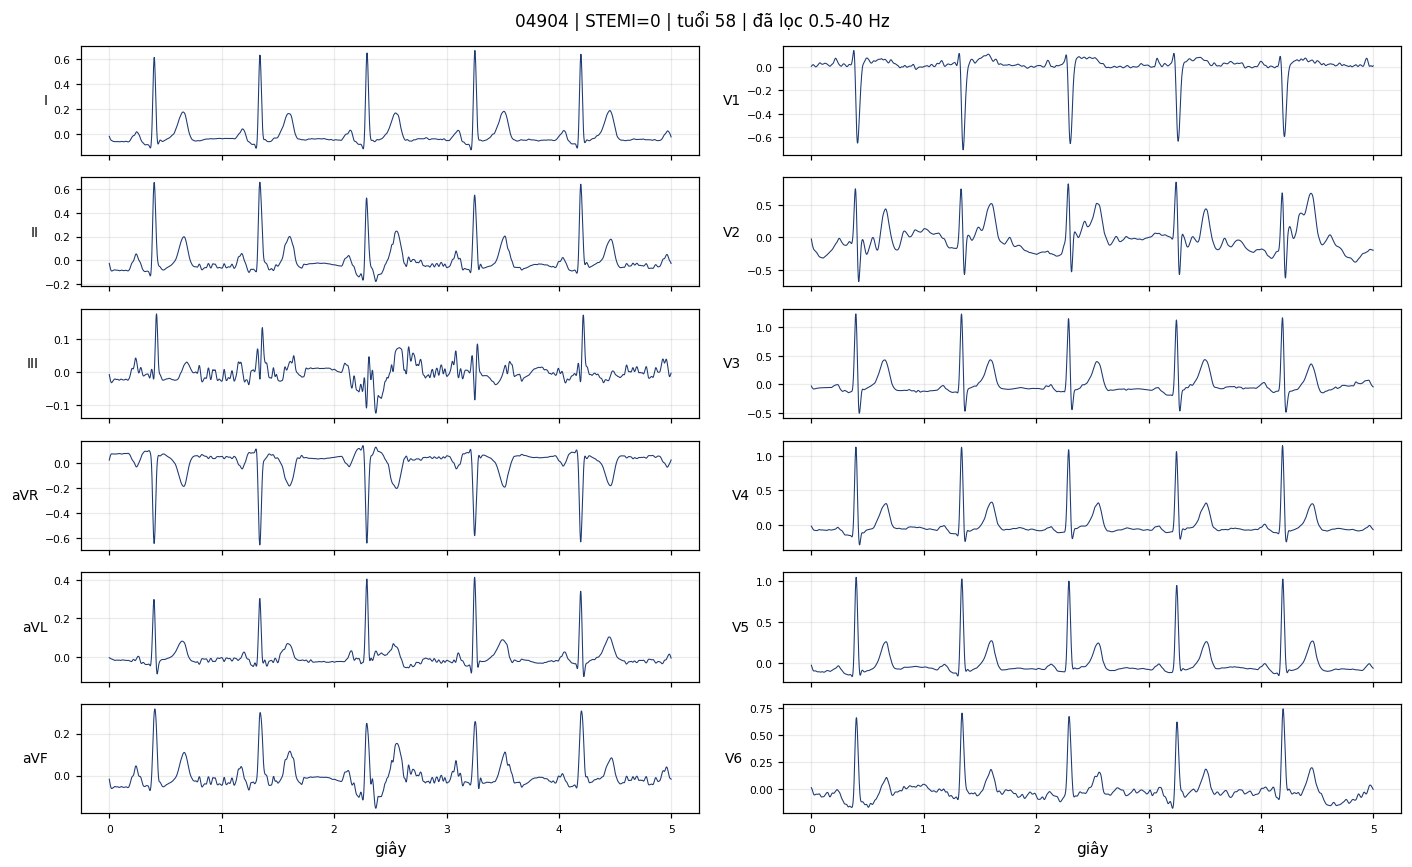

In [9]:
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]


def plot_12lead(sig, title, seconds=5.0):
    n = int(min(SIGNAL_LEN, seconds * FS))
    t = np.arange(n) / FS
    fig, axes = plt.subplots(6, 2, figsize=(13, 8), sharex=True)
    for k, ax in enumerate(axes.T.flatten()):
        ax.plot(t, sig[k, :n], lw=.7, color="#1f3b73")
        ax.set_ylabel(LEADS[k], rotation=0, ha="right", va="center", fontsize=9)
        ax.grid(alpha=.25)
        ax.tick_params(labelsize=7)
    axes[-1, 0].set_xlabel("giây")
    axes[-1, 1].set_xlabel("giây")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


for idx in list(df.index[df[TARGET_LABEL] == 1][:1]) + list(df.index[df[TARGET_LABEL] == 0][:1]):
    r = df.loc[idx]
    plot_12lead(np.asarray(CACHE[idx], dtype=np.float32),
                f"{r['record_stem']} | {TARGET_LABEL}={int(r[TARGET_LABEL])} | "
                f"tuổi {int(r[COL_AGE])} | đã lọc 0.5-40 Hz")

## 9. Chia train/val theo bệnh nhân

Bắt buộc chia theo `Patient_id`: một bệnh nhân có thể có nhiều ECG trong 7 ngày trước DSA, chia theo
bản ghi sẽ khiến cùng một người xuất hiện ở cả train lẫn val.

Stratify ở **cấp bệnh nhân** (lấy `max` nhãn của người đó) — cần thiết vì có bệnh nhân mang nhãn
không đồng nhất giữa các bản ghi của chính mình (xem mục 6).

Ngay sau khi chia, mean/std cho z-score được tính **chỉ trên các bản ghi thuộc train**.

In [10]:
pat = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
strat = pat[TARGET_LABEL] if pat[TARGET_LABEL].value_counts().min() >= 2 else None
pat_tr, pat_va = train_test_split(pat, test_size=VAL_SIZE, stratify=strat, random_state=SEED)

train_idx = df.index[df[COL_PATIENT].isin(set(pat_tr[COL_PATIENT]))].to_numpy()
val_idx = df.index[df[COL_PATIENT].isin(set(pat_va[COL_PATIENT]))].to_numpy()
y = df[TARGET_LABEL].values.astype(np.float32)

assert not (set(pat_tr[COL_PATIENT]) & set(pat_va[COL_PATIENT])), "RÒ RỈ: bệnh nhân ở cả 2 tập"
print("Giao nhau patient_id: RỖNG -> OK\n")

display(pd.DataFrame({
    "tập": ["train", "val"],
    "bệnh nhân": [len(pat_tr), len(pat_va)],
    "bản ghi": [len(train_idx), len(val_idx)],
    "dương": [int(y[train_idx].sum()), int(y[val_idx].sum())],
    "tỷ lệ dương": [f"{y[train_idx].mean():.2%}", f"{y[val_idx].mean():.2%}"],
}))


def norm_stats(idx, chunk=256):
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(CACHE[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


LEAD_MEAN, LEAD_STD = norm_stats(train_idx)
print(f"\nz-score fit trên {len(train_idx):,} bản ghi TRAIN")

Giao nhau patient_id: RỖNG -> OK



,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,train,14465,15264,1225,8.03%
1,val,2553,2696,217,8.05%



z-score fit trên 15,264 bản ghi TRAIN


## 10. Dataset & DataLoader

In [11]:
from torch.utils.data import DataLoader, Dataset


class ECGDataset(Dataset):
    def __init__(self, indices, labels):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = LEAD_MEAN.reshape(-1, 1)
        self.std = LEAD_STD.reshape(-1, 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x = np.asarray(CACHE[self.indices[i]], dtype=np.float32)
        return torch.from_numpy((x - self.mean) / self.std), torch.tensor(self.labels[i])


# Windows tạo worker bằng spawn (mỗi worker nạp lại cả notebook) nên để 0; Linux dùng fork -> 2
NUM_WORKERS = 0 if os.name == "nt" else 2
_extra = dict(persistent_workers=True, prefetch_factor=4) if NUM_WORKERS else {}

train_loader = DataLoader(ECGDataset(train_idx, y[train_idx]), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
val_loader = DataLoader(ECGDataset(val_idx, y[val_idx]), batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)

xb, yb = next(iter(train_loader))
print(f"batch: {tuple(xb.shape)} {xb.dtype} | nhãn {tuple(yb.shape)} | "
      f"{len(train_loader)} batch train, {len(val_loader)} batch val")

batch: (64, 12, 5000) torch.float32 | nhãn (64,) | 239 batch train, 43 batch val


## 11. Hàm tính metric

`compute_metrics` an toàn với tập nhỏ: khi chỉ có một lớp hoặc mẫu số bằng 0, trả `nan` thay vì
ném lỗi hay trả 0 gây hiểu nhầm.

`per_class_report` cho bảng tách riêng **lớp âm tính (0)** và **lớp dương tính (1)** — mỗi lớp có
Precision/Recall/F1/Support riêng, kèm hai dòng trung bình macro và weighted.

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "accuracy": _div(tp + tn, tp + tn + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "threshold": float(threshold),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


def per_class_report(y_true, y_prob, threshold):
    """Bảng metric TÁCH RIÊNG cho lớp 0 và lớp 1, kiểu classification_report của sklearn."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = (np.asarray(y_prob).ravel() >= threshold).astype(int)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    rows = [
        {"Class": f"Negative (0) — không {CLASS_NAME}", "Precision": p[0], "Recall": r[0],
         "F1": f[0], "Support": int(s[0])},
        {"Class": f"Positive (1) — {CLASS_NAME}", "Precision": p[1], "Recall": r[1],
         "F1": f[1], "Support": int(s[1])},
    ]
    w = s / s.sum()
    rows.append({"Class": "macro avg", "Precision": p.mean(), "Recall": r.mean(),
                 "F1": f.mean(), "Support": int(s.sum())})
    rows.append({"Class": "weighted avg", "Precision": float(p @ w), "Recall": float(r @ w),
                 "F1": float(f @ w), "Support": int(s.sum())})
    return pd.DataFrame(rows).set_index("Class")


def style_df(df, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df.columns if c not in pct_cols and df[c].dtype.kind in "iu"})
    try:
        return df.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df.columns])
    except Exception:
        return df.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})

self-test: {'auroc': np.float64(0.75), 'sensitivity': 0.5, 'f1': 0.667}


## 12. Mô hình

1D CNN residual gọn nhẹ (~1,0M tham số):

```
Input (batch, 12, 5000)
Stem : Conv1d(12→32, k=15, s=2) → BN → ReLU → MaxPool(2)
4 × ResidualBlock1D  (kênh ra 32 → 64 → 128 → 256, mỗi block stride 2)
GlobalAvgPool → FC(256→64) → ReLU → Dropout(0.3) → FC(64→1)   [logit]
```

Trả về **logit** (chưa qua sigmoid) để dùng thẳng với `BCEWithLogitsLoss`.

In [13]:
import torch.nn as nn


class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ECGResNet1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False), nn.BatchNorm1d(32),
            nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.pool(self.blocks(self.stem(x)))).squeeze(-1)


model = ECGResNet1D().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
with torch.no_grad():
    probe = model(torch.zeros(2, NUM_LEADS, SIGNAL_LEN, device=DEVICE))
print(f"ECGResNet1D — {n_params:,} tham số | output {tuple(probe.shape)} (logit)")

ECGResNet1D — 986,753 tham số | output (2,) (logit)


## 13. Huấn luyện

- `BCEWithLogitsLoss(pos_weight = số âm / số dương)` tính từ tỷ lệ lớp thực tế trong tập train
- AdamW, `ReduceLROnPlateau` theo val AUPRC (patience 5), early stopping patience 10
- AMP khi có GPU; checkpoint ghi thẳng vào `MODEL_DIR` (trên Colab là Drive) mỗi 5 epoch

**Chạy lại được sau khi mất phiên.** Cell tự tìm checkpoint cũ và train tiếp từ đúng epoch đang dở,
thay vì bắt đầu lại từ đầu. Nó chỉ nối tiếp khi checkpoint khớp `RUN_MODE`, nhãn và kích thước tập
train — nên checkpoint của lần chạy debug không bị nhặt nhầm vào lần chạy full.

In [14]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

n_pos_tr = int(y[train_idx].sum())
POS_WEIGHT = float((len(train_idx) - n_pos_tr) / max(n_pos_tr, 1))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=LR_PATIENCE)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

CKPT = MODEL_DIR / "checkpoint_last.pt"
CKPT_BEST = MODEL_DIR / "checkpoint_best.pt"
FINGERPRINT = dict(run_mode=RUN_MODE, target=TARGET_LABEL, n_train=len(train_idx))
STATE = {"epoch": 0, "best": -np.inf, "best_epoch": -1, "bad": 0, "hist": [], "early": False}


def run_epoch(loader, train):
    model.train(train)
    tot, seen, ys, ps = 0.0, 0, [], []
    with (torch.enable_grad() if train else torch.no_grad()):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
                loss = criterion(logits, yb)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            tot += loss.item() * xb.size(0)
            seen += xb.size(0)
            ys.append(yb.detach().cpu().numpy())
            ps.append(torch.sigmoid(logits.detach().float()).cpu().numpy())
    return tot / max(seen, 1), np.concatenate(ys), np.concatenate(ps)


def save(path):
    torch.save({"model": model.state_dict(), "opt": optimizer.state_dict(),
                "sched": scheduler.state_dict(), "scaler": scaler.state_dict(),
                "state": dict(STATE), "fp": FINGERPRINT,
                "mean": LEAD_MEAN, "std": LEAD_STD}, path)


# --- nối tiếp nếu có checkpoint khớp ---
if CKPT.exists():
    ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
    if ck.get("fp") == FINGERPRINT:
        model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["opt"])
        scheduler.load_state_dict(ck["sched"]); scaler.load_state_dict(ck["scaler"])
        STATE.update(ck["state"])
        print(f"Nối tiếp checkpoint: đã train {STATE['epoch']}/{EPOCHS} epoch")
    else:
        print("Có checkpoint cũ nhưng khác cấu hình -> train lại từ đầu")

print(f"pos_weight = {POS_WEIGHT:.2f}\n")
t_all = time.time()
for epoch in range(STATE["epoch"], EPOCHS):
    t0 = time.time()
    tr_loss, tr_y, tr_p = run_epoch(train_loader, True)
    va_loss, va_y, va_p = run_epoch(val_loader, False)
    tr_m, va_m = compute_metrics(tr_y, tr_p), compute_metrics(va_y, va_p)
    scheduler.step(va_m["auprc"] if not np.isnan(va_m["auprc"]) else -np.inf)

    STATE["epoch"] = epoch + 1
    STATE["hist"].append({"epoch": epoch + 1, "train_loss": tr_loss, "val_loss": va_loss,
                          "train_auprc": tr_m["auprc"], "val_auprc": va_m["auprc"],
                          "val_auroc": va_m["auroc"], "sec": round(time.time() - t0, 1)})

    better = (not np.isnan(va_m["auprc"])) and va_m["auprc"] > STATE["best"]
    if better:
        STATE.update(best=float(va_m["auprc"]), best_epoch=epoch + 1, bad=0)
        save(CKPT_BEST)
    else:
        STATE["bad"] += 1

    print(f"epoch {epoch + 1:>3}/{EPOCHS} | {time.time() - t0:5.1f}s | "
          f"train loss {tr_loss:.4f} | val loss {va_loss:.4f} "
          f"auprc {va_m['auprc']:.4f} auroc {va_m['auroc']:.4f}"
          f"{'  <-- best' if better else ''}")

    if (epoch + 1) % 5 == 0:
        save(CKPT)
    if STATE["bad"] >= EARLY_STOP_PATIENCE:
        print(f"Early stopping (val AUPRC không cải thiện {EARLY_STOP_PATIENCE} epoch)")
        STATE["early"] = True
        break

save(CKPT)
print(f"\nXong {STATE['epoch']} epoch trong {time.time() - t_all:.0f}s | "
      f"best val AUPRC {STATE['best']:.4f} @ epoch {STATE['best_epoch']}")

pos_weight = 11.46



epoch   1/30 |  19.1s | train loss 0.8598 | val loss 0.8962 auprc 0.3424 auroc 0.8673  <-- best


epoch   2/30 |   4.9s | train loss 0.7333 | val loss 0.7634 auprc 0.5212 auroc 0.8985  <-- best


epoch   3/30 |   4.8s | train loss 0.7030 | val loss 0.8292 auprc 0.4568 auroc 0.8864


epoch   4/30 |   4.9s | train loss 0.6465 | val loss 0.7119 auprc 0.5280 auroc 0.9067  <-- best


...

epoch  26/30 |   8.7s | train loss 0.3384 | val loss 0.7170 auprc 0.6167 auroc 0.9243


epoch  27/30 |   7.8s | train loss 0.3428 | val loss 0.8432 auprc 0.6445 auroc 0.9222


epoch  28/30 |   7.5s | train loss 0.3239 | val loss 1.1097 auprc 0.6351 auroc 0.9193


epoch  29/30 |   7.8s | train loss 0.2618 | val loss 1.0479 auprc 0.6301 auroc 0.9266


epoch  30/30 |   7.7s | train loss 0.2332 | val loss 1.3475 auprc 0.6259 auroc 0.9239

Xong 30 epoch trong 190s | best val AUPRC 0.6519 @ epoch 22


## 14. Đường cong học

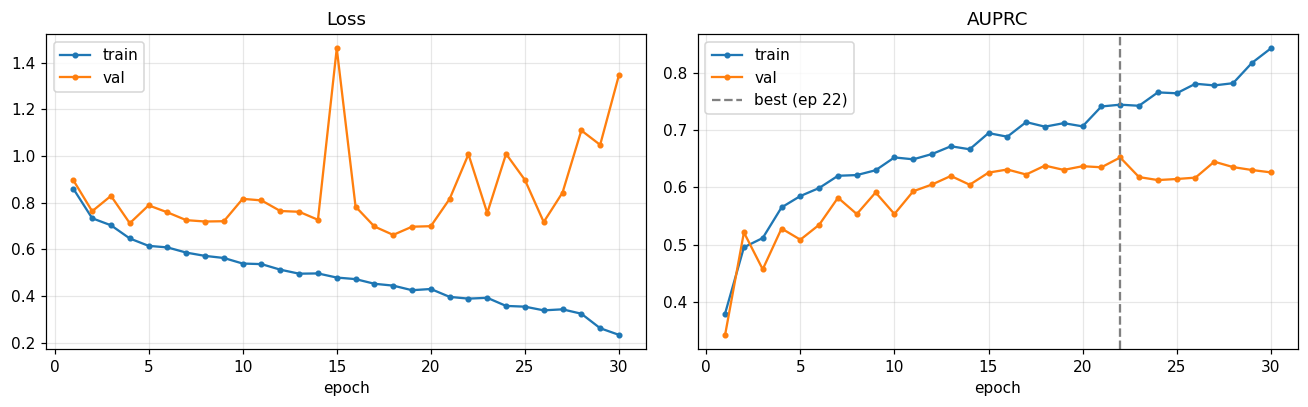

,epoch,train_loss,val_loss,train_auprc,val_auprc,val_auroc,sec
20,21,0.396086,0.816116,0.740905,0.634801,0.921381,5.6
21,22,0.388598,1.007626,0.744025,0.651939,0.918249,5.7
22,23,0.392141,0.755709,0.742113,0.617704,0.915687,5.9
23,24,0.357292,1.009113,0.765470,0.612512,0.917543,8.0
24,25,0.354217,0.897610,0.763912,0.614344,0.924567,7.6
25,26,0.338350,0.717001,0.780543,0.616749,0.924327,8.7
26,27,0.342763,0.843201,0.777634,0.644541,0.922200,7.8
27,28,0.323877,1.109698,0.781510,0.635129,0.919269,7.5
28,29,0.261806,1.047943,0.816878,0.630060,0.926627,7.8
29,30,0.233215,1.347492,0.842060,0.625941,0.923938,7.7


In [15]:
hist = pd.DataFrame(STATE["hist"])
if len(hist):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    ax[0].plot(hist.epoch, hist.train_loss, marker="o", ms=3, label="train")
    ax[0].plot(hist.epoch, hist.val_loss, marker="o", ms=3, label="val")
    ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist.epoch, hist.train_auprc, marker="o", ms=3, label="train")
    ax[1].plot(hist.epoch, hist.val_auprc, marker="o", ms=3, label="val")
    if STATE["best_epoch"] > 0:
        ax[1].axvline(STATE["best_epoch"], ls="--", c="gray", label=f"best (ep {STATE['best_epoch']})")
    ax[1].set_title("AUPRC"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
display(hist.tail(10))

## 15. Kết quả trên tập validation

Nạp checkpoint tốt nhất (epoch có val AUPRC cao nhất), chọn ngưỡng theo **Youden's J**
(= Sensitivity + Specificity − 1), rồi in **bảng metric tách riêng lớp 0 và lớp 1**.

Cách đọc: `Support` là số bản ghi thật của từng lớp. Với bài toán mất cân bằng, dòng `weighted avg`
bị lớp âm tính chi phối nên nhìn đẹp mà ít ý nghĩa — **hãy đọc dòng `Positive (1)`** để biết mô hình
thực sự làm được gì với ca bệnh.

In [16]:
from sklearn.metrics import precision_recall_curve, roc_curve

ck = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model"])
model.eval()
_, val_y, val_p = run_epoch(val_loader, False)

# --- chọn ngưỡng ---
if len(np.unique(val_y.astype(int))) == 2:
    fpr, tpr, thr = roc_curve(val_y, val_p)
    THRESHOLD = float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))
    grid = np.linspace(.01, .99, 99)
    THR_F1 = float(grid[int(np.nanargmax([compute_metrics(val_y, val_p, t)["f1"] for t in grid]))])
else:
    THRESHOLD = THR_F1 = 0.5

M = compute_metrics(val_y, val_p, THRESHOLD)

print("=" * 76)
print(f"{CLASS_NAME}  (checkpoint epoch {ck['state']['best_epoch']})")
print(f"AUROC {M['auroc']:.4f}   AUPRC {M['auprc']:.4f}   "
      f"Prevalence {M['n_pos'] / M['n']:.4f}   "
      f"(AUPRC gấp {M['auprc'] / (M['n_pos'] / M['n']):.2f}x mức ngẫu nhiên)")
print(f"Ngưỡng {THRESHOLD:.4f} (Youden's J)   Accuracy {M['accuracy']:.4f}   "
      f"TP {M['tp']}  TN {M['tn']}  FP {M['fp']}  FN {M['fn']}")
print("=" * 76)

display(style_df(per_class_report(val_y, val_p, THRESHOLD), ["Precision", "Recall", "F1"]))

# --- ba cách chọn ngưỡng ---
rows = []
for name, t in [("mặc định 0.5", 0.5), ("Youden's J", THRESHOLD), ("F1-max", THR_F1)]:
    m = compute_metrics(val_y, val_p, t)
    rows.append({"Ngưỡng": name, "giá trị": t, "Precision": m["ppv"], "Recall": m["sensitivity"],
                 "Specificity": m["specificity"], "F1": m["f1"], "NPV": m["npv"],
                 "TP": m["tp"], "FP": m["fp"], "FN": m["fn"]})
print("\nCùng một mô hình, chỉ khác điểm cắt (AUROC/AUPRC không đổi):")
display(style_df(pd.DataFrame(rows).set_index("Ngưỡng"),
                 ["giá trị", "Precision", "Recall", "Specificity", "F1", "NPV"]))

if not np.isnan(M["auroc"]) and M["auroc"] < 0.75:
    print("\n" + "!" * 76)
    print(f"!! CẢNH BÁO: AUROC = {M['auroc']:.4f} < 0.75.")
    print("!! STEMI là pattern tương đối dễ nhận diện trên ECG, nên AUROC thấp thế này")
    print("!! nhiều khả năng là dấu hiệu BUG chứ không phải giới hạn của bài toán.")
    print("!! Kiểm tra: nhãn (mục 4), thứ tự chuyển đạo (mục 7), rò rỉ split (mục 9), z-score.")
    if RUN_MODE == "debug":
        print("!! (Đang ở debug với ~200 bản ghi — AUROC thấp là BÌNH THƯỜNG.)")
    print("!" * 76)
elif not np.isnan(M["auroc"]):
    print(f"\n-> ĐẠT: AUROC {M['auroc']:.4f} >= 0.75")


STEMI  (checkpoint epoch 22)
AUROC 0.9182   AUPRC 0.6519   Prevalence 0.0805   (AUPRC gấp 8.10x mức ngẫu nhiên)
Ngưỡng 0.3367 (Youden's J)   Accuracy 0.8557   TP 189  TN 2118  FP 361  FN 28


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không STEMI,0.9870,0.8544,0.9159,"2,479"
Positive (1) — STEMI,0.3436,0.8710,0.4928,217
macro avg,0.6653,0.8627,0.7044,"2,696"
weighted avg,0.9352,0.8557,0.8818,"2,696"



Cùng một mô hình, chỉ khác điểm cắt (AUROC/AUPRC không đổi):


,giá trị,Precision,Recall,Specificity,F1,NPV,TP,FP,FN
Ngưỡng,,,,,,,,,
mặc định 0.5,0.5000,0.3880,0.8065,0.8887,0.5240,0.9813,175,276,42
Youden's J,0.3367,0.3436,0.8710,0.8544,0.4928,0.9870,189,361,28
F1-max,0.9400,0.7070,0.5115,0.9814,0.5936,0.9583,111,46,106



-> ĐẠT: AUROC 0.9182 >= 0.75


## 15b. Bảng tóm tắt kết quả

Một dòng, các metric chính — tiện để chụp màn hình hoặc dán vào báo cáo.

In [ ]:
summary_df = pd.DataFrame([{
    "Mô hình": "ECGResNet1D",
    "AUROC": M["auroc"], "AUPRC": M["auprc"], "F1": M["f1"],
    "Precision": M["ppv"], "Sensitivity": M["sensitivity"],
    "Specificity": M["specificity"], "Accuracy": M["accuracy"],
}]).set_index("Mô hình")
display(style_df(summary_df, summary_df.columns.tolist()))

## 16. Confusion matrix, ROC và PR

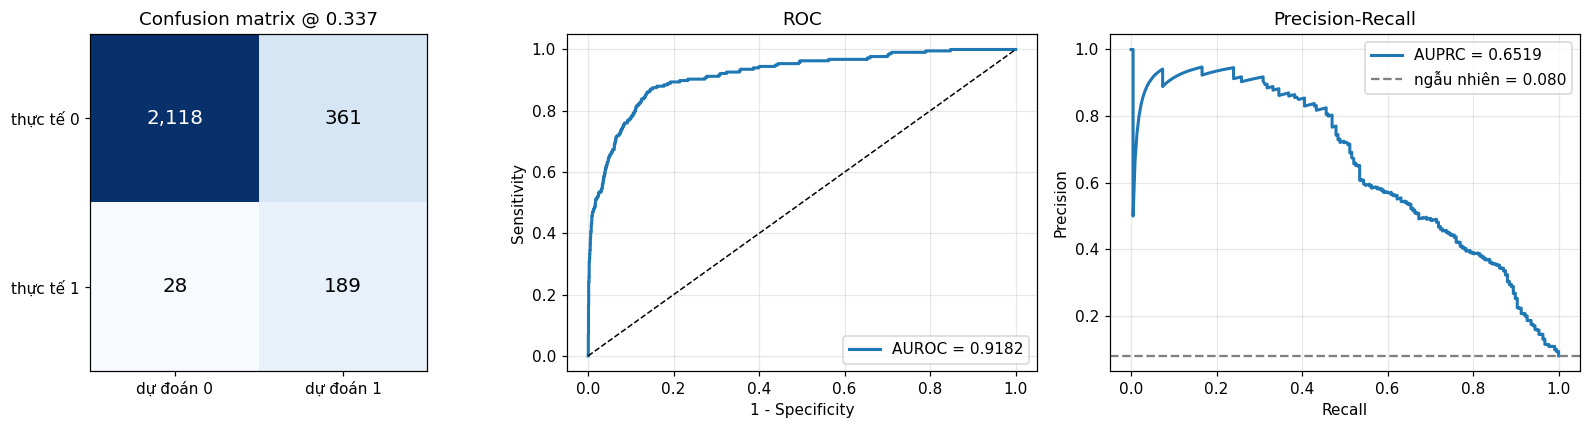

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

cm = np.array([[M["tn"], M["fp"]], [M["fn"], M["tp"]]])
ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1], ["dự đoán 0", "dự đoán 1"])
ax[0].set_yticks([0, 1], ["thực tế 0", "thực tế 1"])
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                   color="white" if cm[i, j] > cm.max() / 2 else "black")
ax[0].set_title(f"Confusion matrix @ {THRESHOLD:.3f}")

if len(np.unique(val_y.astype(int))) == 2:
    ax[1].plot(fpr, tpr, lw=2, label=f"AUROC = {M['auroc']:.4f}")
    ax[1].plot([0, 1], [0, 1], "k--", lw=1)
    ax[1].set_xlabel("1 - Specificity"); ax[1].set_ylabel("Sensitivity")
    ax[1].set_title("ROC"); ax[1].legend(); ax[1].grid(alpha=.3)

    prec, rec, _ = precision_recall_curve(val_y, val_p)
    base = float(np.mean(val_y))
    ax[2].plot(rec, prec, lw=2, label=f"AUPRC = {M['auprc']:.4f}")
    ax[2].axhline(base, ls="--", c="gray", label=f"ngẫu nhiên = {base:.3f}")
    ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
    ax[2].set_title("Precision-Recall"); ax[2].legend(); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 17. Hiệu chuẩn xác suất (ECE)

Đầu ra của hệ thống là **xác suất liên tục**, nên độ tin cậy của con số quan trọng ngang khả năng
phân biệt. ECE đo trung bình khoảng cách giữa xác suất mô hình nói và tỷ lệ đúng thực tế.

`pos_weight` cố tình đẩy xác suất về phía lớp dương để bù mất cân bằng, nên **ECE cao là điều đã
được dự báo trước** — muốn dùng xác suất tuyệt đối thì phải hiệu chuẩn lại (Platt/isotonic) trên
một tập riêng.

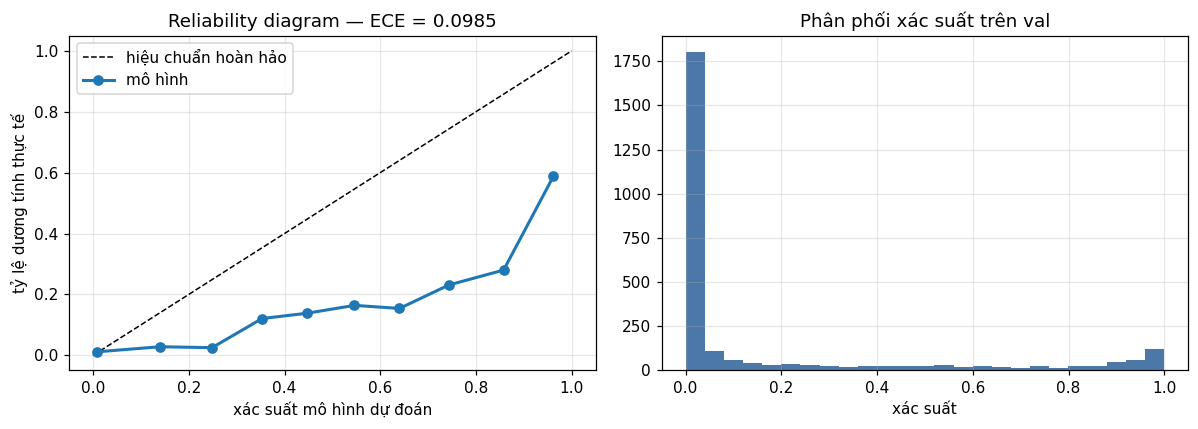

ECE = 0.0985 | Brier = 0.0856


,bin,n,xác suất TB,tỷ lệ dương thật,lệch
0,"[0.0,0.1)",1942,0.0078,0.0113,0.0035
1,"[0.1,0.2)",107,0.1402,0.0280,-0.1121
2,"[0.2,0.3)",80,0.2487,0.0250,-0.2237
3,"[0.3,0.4)",58,0.3531,0.1207,-0.2324
4,"[0.4,0.5)",58,0.4463,0.1379,-0.3083
5,"[0.5,0.6)",61,0.5463,0.1639,-0.3823
6,"[0.6,0.7)",52,0.6403,0.1538,-0.4864
7,"[0.7,0.8)",52,0.7433,0.2308,-0.5125
8,"[0.8,0.9)",75,0.8580,0.2800,-0.5780
9,"[0.9,1.0)",211,0.9619,0.5877,-0.3742


In [18]:
def ece_table(y_true, y_prob, n_bins=ECE_BINS):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    ece, rows = 0.0, []
    for b in range(n_bins):
        m = idx == b
        if not m.sum():
            continue
        conf, acc = float(y_prob[m].mean()), float(y_true[m].mean())
        ece += m.sum() / len(y_prob) * abs(acc - conf)
        rows.append({"bin": f"[{edges[b]:.1f},{edges[b + 1]:.1f})", "n": int(m.sum()),
                     "xác suất TB": conf, "tỷ lệ dương thật": acc, "lệch": acc - conf})
    return float(ece), pd.DataFrame(rows)


ECE, tbl = ece_table(val_y, val_p)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="hiệu chuẩn hoàn hảo")
ax[0].plot(tbl["xác suất TB"], tbl["tỷ lệ dương thật"], marker="o", lw=2, label="mô hình")
ax[0].set_xlabel("xác suất mô hình dự đoán"); ax[0].set_ylabel("tỷ lệ dương tính thực tế")
ax[0].set_title(f"Reliability diagram — ECE = {ECE:.4f}"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(val_p, bins=25, color="#4C78A8")
ax[1].set_title("Phân phối xác suất trên val"); ax[1].set_xlabel("xác suất"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"ECE = {ECE:.4f} | Brier = {M['brier']:.4f}")
display(tbl.round(4))

## 18. Chuyển từ chạy thử sang chạy thật

Ở **mục 2**, đổi `RUN_MODE = "debug"` thành `RUN_MODE = "full"` rồi **Run all**. Không cần sửa gì khác.

| | debug | full |
|---|---|---|
| bản ghi | 200 (stratified) | toàn bộ 17.960 |
| epoch | 3 | 30 (early stopping patience 10) |
| batch size | 8 | 64 (GPU) / 16 (CPU) |
| cache | `sig_debug_*.npy` | `sig_full_*.npy` (~2,2 GB) |

Lần chạy `full` đầu tiên phải build lại cache (debug và full là hai file riêng) — đây là phần tốn
thời gian nhất; các lần sau cache được dùng lại.

**Nếu phiên Colab bị đứt:** Run all lại. Cache build nối tiếp từ chỗ dừng, và mục 13 nạp
`checkpoint_last.pt` để train tiếp từ đúng epoch đang dở.

**Muốn so sánh nhiều kiến trúc khác nhau** cho cùng bài toán này: mở `03_stemi_model_comparison.ipynb`.